# Olist: кто покупает повторно

## 1. О проекте и данных

**Какие категории первой покупки подходят для теста второй покупки и как повторные покупки различаются при доставке вовремя и с опозданием?**

Источник — [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). Учитываем заказы со статусом `delivered`; покупатель определяется через `customer_unique_id`. Граница наблюдения — **31 июля 2018, 23:59:59**.

В `data/buyer_analysis.csv` одна строка соответствует покупателю с полными 180 днями наблюдения. SQL объединяет первые одновременные заказы, определяет категорию и доставку.

Два дополнительных окна после получения рассчитаны по всем последующим заказам и сохранены в `data/delivery_after_receipt.csv`. Одной даты ближайшего повтора для них недостаточно. Как получить обе выгрузки из исходных данных, описано в README.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline

blue, orange, grey = "#3D5AFE", "#FF8A3D", "#B6C2D6"
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

cutoff = pd.Timestamp("2018-07-31 23:59:59")
window = pd.Timedelta(days=180)
data = pd.read_csv("data/buyer_analysis.csv")
for column in ["first_purchase_at", "next_purchase_at", "first_purchase_delivered_at"]:
    data[column] = pd.to_datetime(data[column])

assert data["customer_unique_id"].is_unique
assert (data["first_purchase_at"] + window <= cutoff).all()
next_dates = data["next_purchase_at"].dropna()
assert next_dates.gt(data.loc[next_dates.index, "first_purchase_at"]).all()
assert data["first_purchase_month"].eq(data["first_purchase_at"].dt.strftime("%Y-%m")).all()

returned = data["next_purchase_at"].le(data["first_purchase_at"] + window)
assert returned.astype(int).eq(data["returned_180"]).all()
known_delivery = data["delivery_group"].isin(["on_time", "late"])
assert data.loc[known_delivery, "first_purchase_delivered_at"].ge(
    data.loc[known_delivery, "first_purchase_at"]
).all()

data["repeat_before_delivery"] = (
    data["returned_180"].eq(1)
    & data["next_purchase_at"].le(data["first_purchase_delivered_at"])
).astype(int)

## 2. Повторные покупки

Повтор — доставленный заказ с **более поздним временем оформления**, не позже 180 дней от первой наблюдаемой покупки. Одновременные первые заказы повтором не являются; следующая покупка может быть в любой категории.

В выборку входят покупатели, у которых все 180 дней заканчиваются не позже границы наблюдения. Так у каждого есть одинаковый срок для повторной покупки.

In [2]:
overall_rate = data["returned_180"].mean() * 100
overview = pd.DataFrame({
    "Покупатели": [len(data)],
    "Купили снова": [data["returned_180"].sum()],
    "Доля, %": [overall_rate],
})
display(overview.style.format(precision=2, decimal=",", thousands=" "))

,Покупатели,Купили снова,"Доля, %"
0,49 452,1 358,"2,75"


За 180 дней снова купили **1 358 из 49 452 покупателей — 2,75%**. Olist — маркетплейс с разными товарными категориями, поэтому этот процент сам по себе не говорит о плохом удержании. Отсутствие повтора за полгода также не означает окончательный уход покупателя.

## 3. Категории первой покупки

Категория определяется по **всем товарам первых одновременных заказов**. Несколько известных категорий дают `mixed_categories`; хотя бы один товар без категории — `unknown_category`.

Сравним 17 категорий, в которых было не менее 1 000 покупателей. Малые группы оставим для разбора отдельных случаев.

In [3]:
names = {
    "bed_bath_table": "Домашний текстиль",
    "sports_leisure": "Спорт и досуг",
    "health_beauty": "Здоровье и красота",
    "furniture_decor": "Мебель и декор",
    "computers_accessories": "Компьютеры и аксессуары",
    "housewares": "Товары для дома",
    "toys": "Игрушки",
    "cool_stuff": "Cool stuff",
    "watches_gifts": "Часы и подарки",
    "telephony": "Телефония",
    "garden_tools": "Садовые инструменты",
    "perfumery": "Парфюмерия",
    "auto": "Автотовары",
    "baby": "Товары для малышей",
    "stationery": "Канцтовары",
    "electronics": "Электроника",
    "fashion_bags_accessories": "Сумки и аксессуары",
}
categories = data.groupby("first_category")["returned_180"].agg(
    buyers="size", returned_buyers="sum"
)
categories["repeat_rate_pct"] = categories["returned_buyers"] / categories["buyers"] * 100
selected = ["fashion_bags_accessories", "bed_bath_table", "cool_stuff"]
category_table = categories.loc[selected].rename(index=names, columns={
    "buyers": "Покупатели", "returned_buyers": "Купили снова", "repeat_rate_pct": "Доля, %"
})
category_table.index.name = "Первая категория"
display(category_table.style.format(precision=2, decimal=",", thousands=" "))

,Покупатели,Купили снова,"Доля, %"
Первая категория,,,
Сумки и аксессуары,1 039,50,"4,81"
Домашний текстиль,4 769,214,"4,49"
Cool stuff,2 382,31,"1,30"


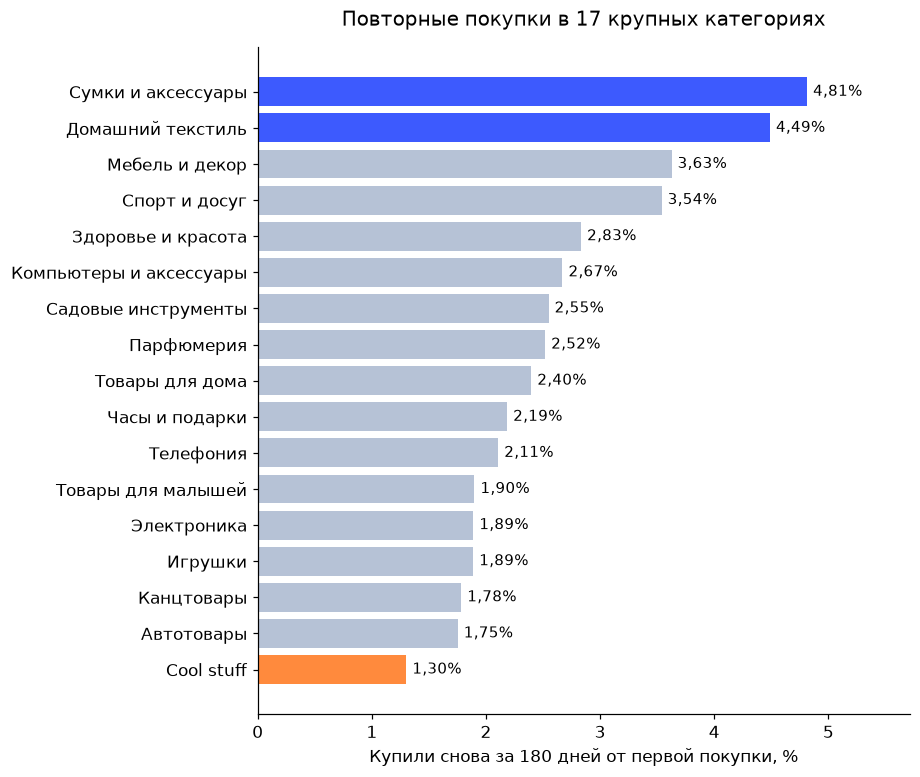

In [4]:
ranking = categories[categories["buyers"].ge(1000)].sort_values("repeat_rate_pct")
colors = [
    blue if category in selected[:2] else orange if category == "cool_stuff" else grey
    for category in ranking.index
]
fig, ax = plt.subplots(figsize=(8.5, 7.2))
ax.barh(range(len(ranking)), ranking["repeat_rate_pct"], color=colors)
ax.set_yticks(range(len(ranking)), [names.get(category, category) for category in ranking.index])
ax.bar_label(ax.containers[0], labels=[
    f"{value:.2f}%".replace(".", ",")
    for value in ranking["repeat_rate_pct"]
], padding=4, fontsize=10)
ax.set_xlim(0, ranking["repeat_rate_pct"].max() + 0.9)
ax.set_title("Повторные покупки в 17 крупных категориях", pad=14)
ax.set_xlabel("Купили снова за 180 дней от первой покупки, %")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

У сумок доля повторных покупателей — **4,81%**, у домашнего текстиля — **4,49%**, у Cool stuff — **1,30%**. Домашний текстиль близок к сумкам по доле повторов, а его база больше в 4,6 раза: 4 769 покупателей против 1 039.

Общие доли могут зависеть от того, в какие месяцы приходили покупатели. Сравнение внутри одного месяца уменьшает влияние разного календарного состава категорий.

У сумок доля выше в 11 из 13 месяцев.


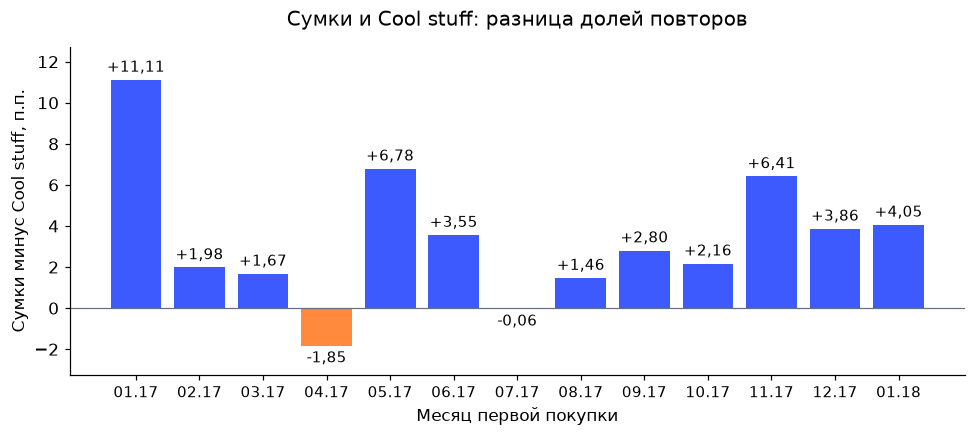

In [5]:
cohort = data[
    data["first_purchase_month"].between("2017-01", "2018-01")
    & data["first_category"].isin(["fashion_bags_accessories", "cool_stuff"])
]
monthly = cohort.groupby(["first_purchase_month", "first_category"])["returned_180"].agg(
    buyers="size", returned_buyers="sum"
)
monthly["repeat_rate_pct"] = monthly["returned_buyers"] / monthly["buyers"] * 100
rates = monthly["repeat_rate_pct"].unstack()
difference = rates["fashion_bags_accessories"] - rates["cool_stuff"]
print(f"У сумок доля выше в {(difference > 0).sum()} из {len(difference)} месяцев.")

fig, ax = plt.subplots(figsize=(9.0, 4.1))
ax.bar(range(len(difference)), difference, color=[blue if value > 0 else orange for value in difference])
ax.axhline(0, color="#637087", linewidth=0.8)
ax.bar_label(ax.containers[0], labels=[f"{value:+.2f}".replace(".", ",") for value in difference], padding=3, fontsize=10)
ax.set_xticks(range(len(difference)), [
    f"{month[5:]}.{month[2:4]}"
    for month in difference.index
])
ax.tick_params(axis="x", labelsize=10)
ax.set_ylim(difference.min() - 1.4, difference.max() + 1.6)
ax.set_title("Сумки и Cool stuff: разница долей повторов", pad=14)
ax.set_ylabel("Сумки минус Cool stuff, п.п.")
ax.set_xlabel("Месяц первой покупки")
plt.tight_layout()
plt.show()

У сумок доля выше в **11 из 13 месяцев**; исключения — апрель и июль 2017. Январские **11,11%** у сумок — всего **три повторных покупателя из 27**. Такой пик чувствителен к единичным покупкам и не даёт отдельного основания для выбора сегмента.

Сравнение охватывает январь 2017 — январь 2018. В ранних месяцах мало покупателей, а февраль 2018 входит в основную выборку лишь частично. Покупатели одного месяца наблюдаются в близкие календарные периоды, но могут различаться по другим признакам.

## 4. Доставка и повторные покупки

Доставка вовремя означает, что **все первые одновременные заказы** получены не позже обещанного календарного дня. При корректных датах хотя бы один опоздавший заказ относит покупателя к группе опоздания. Неизвестные или некорректные даты дают `unknown_delivery`; два таких покупателя исключены из сравнения.

Полное получение первой покупки — самая поздняя дата получения этих заказов. Используем три определения повторной покупки:

1. Любой повтор за 180 дней **от оформления** первой покупки.
2. Повтор **после полного получения**, но внутри первоначальных 180 дней. Чем дольше доставка, тем короче оставшаяся часть окна.
3. Повтор за полные 180 дней **после получения**. В эту выборку входят только покупатели, у которых новое окно заканчивается не позже границы данных, поэтому численности меньше.

Каждый вариант описывает свою точку отсчёта и условия наблюдения. Основной показатель рассчитывается из выгрузки покупателей; два дополнительных окна — из SQL-выгрузки по всем последующим заказам, включая покупки позже ближайшего повтора.

In [6]:
delivery = data.groupby("delivery_group")["returned_180"].agg(buyers="size", returned_buyers="sum")
base = delivery.loc[["on_time", "late"]].reset_index().assign(window="purchase_180")
after_receipt = pd.read_csv("data/delivery_after_receipt.csv")
checks = pd.concat([base, after_receipt], ignore_index=True)
checks["repeat_rate_pct"] = checks["returned_buyers"] / checks["buyers"] * 100

groups = {"on_time": "Вовремя", "late": "С опозданием"}
receipt_table = checks[checks["window"].eq("delivery_180")].set_index("delivery_group")
receipt_table = receipt_table[["buyers", "returned_buyers", "repeat_rate_pct"]].rename(index=groups, columns={
    "buyers": "Покупатели", "returned_buyers": "Купили снова", "repeat_rate_pct": "Доля, %"
})
receipt_table.index.name = "Первая доставка"
display(receipt_table.style.format(precision=2, decimal=",", thousands=" "))
print(f"Ближайший повтор до получения или одновременно с ним: {data['repeat_before_delivery'].sum()} покупателей.")

,Покупатели,Купили снова,"Доля, %"
Первая доставка,,,
Вовремя,44 279,829,"1,87"
С опозданием,2 332,32,"1,37"


Ближайший повтор до получения или одновременно с ним: 526 покупателей.


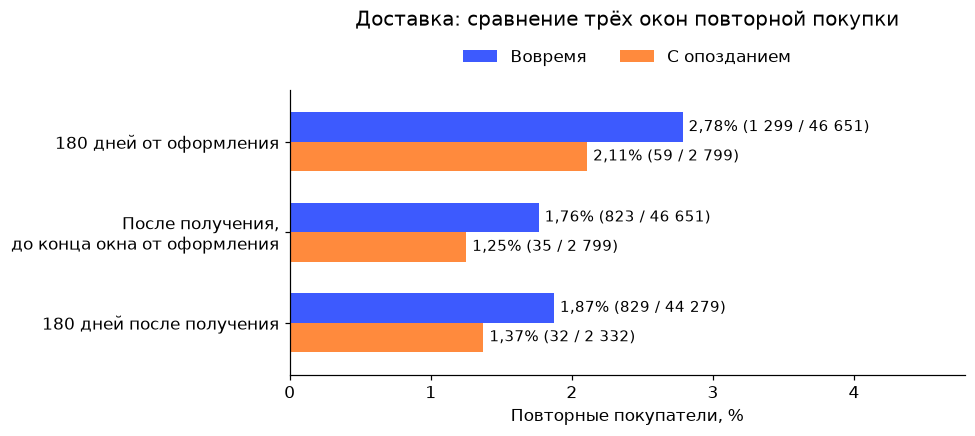

In [7]:
windows = ["purchase_180", "after_delivery_in_purchase_180", "delivery_180"]
window_names = {
    "purchase_180": "180 дней от оформления",
    "after_delivery_in_purchase_180": "После получения,\nдо конца окна от оформления",
    "delivery_180": "180 дней после получения",
}
plot = checks.pivot(index="window", columns="delivery_group", values="repeat_rate_pct")
plot = plot.loc[windows, ["on_time", "late"]].rename(index=window_names, columns=groups)
ax = plot.plot(kind="barh", color=[blue, orange], figsize=(9, 4.1), width=0.65)
ax.invert_yaxis()
for group, bars in zip(["on_time", "late"], ax.containers):
    rows = checks[checks["delivery_group"].eq(group)].set_index("window").loc[windows]
    ax.bar_label(bars, labels=[
        f"{row.repeat_rate_pct:.2f}% ({row.returned_buyers:,} / {row.buyers:,})".replace(",", " ").replace(".", ",")
        for row in rows.itertuples()
    ], padding=4, fontsize=10)
ax.set_xlim(0, checks["repeat_rate_pct"].max() + 2.0)
ax.set_title("Доставка: сравнение трёх окон повторной покупки", pad=42)
ax.set_xlabel("Повторные покупатели, %")
ax.set_ylabel("")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.03), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

За полные **180 дней после получения** повторно купили **829 из 44 279 покупателей с доставкой вовремя — 1,87%**. После опоздания — **32 из 2 332, или 1,37%**. Разница — около **0,50 п.п.**

У **526 из 1 358** повторных покупателей ближайший повтор оформлен до полного получения первой покупки или одновременно с ним. Поэтому показатель от даты оформления нельзя напрямую трактовать как реакцию на полученную доставку.

Группы не уравнены по категориям, цене, продавцу и региону. Наблюдаемая разница не доказывает, что именно задержка снизила повторы. Особенно осторожно нужно читать проценты в малых группах.

In [8]:
cross = cohort[cohort["delivery_group"].isin(groups)].groupby(["first_category", "delivery_group"]).agg(
    buyers=("customer_unique_id", "size"),
    returned_buyers=("returned_180", "sum"),
    repeat_before_delivery=("repeat_before_delivery", "sum"),
)
cross["repeat_rate_pct"] = cross["returned_buyers"] / cross["buyers"] * 100
display(cross.reset_index().replace({"first_category": names, "delivery_group": groups}).rename(columns={
    "first_category": "Категория", "delivery_group": "Доставка",
    "buyers": "Покупатели", "returned_buyers": "Купили снова",
    "repeat_before_delivery": "До получения*", "repeat_rate_pct": "Доля, %",
}).style.format(precision=2, decimal=",", thousands=" "))

,Категория,Доставка,Покупатели,Купили снова,До получения*,"Доля, %"
0,Cool stuff,С опозданием,111,1,0,"0,90"
1,Cool stuff,Вовремя,2 255,29,8,"1,29"
2,Сумки и аксессуары,С опозданием,52,3,2,"5,77"
3,Сумки и аксессуары,Вовремя,976,46,21,"4,71"


В сумках с опозданием **5,77% — три повторных покупателя из 52**. Двое оформили повтор до получения первой покупки. При доставке вовремя — **4,71% (46 из 976)**. Один дополнительный повтор в малой группе изменил бы долю сразу на 1,92 п.п.; высокий процент здесь не подтверждает пользу задержки.

\* «До получения» включает момент получения. Этот пример, как и месячное сравнение, ограничен январём 2017 — январём 2018.

## 5. Главные выводы и рекомендации

**Домашний текстиль — кандидат для CRM-пилота.**

За 180 дней вернулись 1 358 из 49 452 покупателей — 2,75%. Среди крупных категорий лидируют сумки: 50 из 1 039, или 4,81%, и домашний текстиль: 214 из 4 769, или 4,49%.

База домашнего текстиля в 4,6 раза больше, чем у сумок, при близкой исходной доле повторов. Это удобно для набора участников пилота, но не доказывает, что предложение даст больший дополнительный эффект или что сегмент окажется самым выгодным.

**Различие категорий сохраняется внутри месячных когорт.**

У сумок доля повторов выше, чем у Cool stuff, в 11 из 13 месяцев. Сопоставление покупателей одного месяца уменьшает влияние разного календарного состава. При этом январский пик у сумок основан на трёх повторных покупателях из 27 и неустойчив к единичным событиям.

Месяц первой покупки стоит учитывать при распределении участников CRM-теста, чтобы тестовая и контрольная группы были сопоставимы по периоду. Сравнение категорий помогает выбрать гипотезу, но не предсказывает отклик на предложение.

**После опоздания доля повторов ниже примерно на 0,50 п.п.**

За полные 180 дней после получения снова купили 829 из 44 279 покупателей с доставкой вовремя — 1,87%, и 32 из 2 332 покупателей с опозданием — 1,37%. Группы различаются по составу, поэтому причинный эффект задержки здесь не измерен.

Разница даёт основание проверить дополнительную поддержку при задержке. Для оценки реакции на полученную доставку важно учитывать порядок событий: 526 покупателей оформили ближайший повтор до полного получения первой покупки или одновременно с ним.

**Два эксперимента для бизнеса.**

В обоих тестах покупателей случайно распределять в тестовую и контрольную группы и наблюдать полные 180 дней от распределения. Учитывать доставленные повторные заказы, оформленные после этого момента, чтобы покупки до начала теста не попали в результат.

- **CRM-предложение после первой покупки домашнего текстиля.** Среди покупателей, ещё не оформивших второй заказ к моменту сообщения, после полного получения первой покупки сравнить предложение с текущими коммуникациями. Основная метрика — доля покупателей с повтором за 180 дней. Помимо повторов сравнить маржу на покупателя с учётом скидок и стоимости сообщений; проверить, окупается ли предложение.
- **Уведомления и поддержка при задержке.** Среди покупателей с задержкой сравнить дополнительные сообщения и помощь с обычной поддержкой. Основная метрика — доля покупателей с повтором за 180 дней. Учесть стоимость обращений и сообщений, жалобы и отписки. Этот тест оценит эффект поддержки; эффект ускорения доставки требует отдельной проверки.

Перед запуском рассчитать необходимое число участников.

**Ограничения.** Данные исторические; первая наблюдаемая покупка не обязательно первая в жизни клиента. Учитываются только заказы со статусом `delivered`. Категории выбраны после просмотра результатов, группы доставки не уравнены по составу покупателей. Причинные эффекты, маркетинговые каналы и стоимость привлечения здесь не оценены. Низкая доля повторов не означает плохое удержание, а отсутствие покупки за 180 дней — окончательный уход.